# Chapter 18 - NP-Completeness

## Learning Objectives

After completing this chapter, you will be able to:

* Define a metric graph.
* State the traveling salesman problem and know how to check solutions.
* Understand the idea of a polynomial time reduction from one problem to another.
* Recall the satisfiability (SAT) problem.
* Conceptually understand the idea of NP-completeness.

We use these libraries to build and visualize the objects we'll be using in this chapter:

| Package | Purpose |
|---|---|
| `io` | Basic library for handling input and output |
| `base64` | Manages special characters |
| `IPython` | Provides additional Python functionality |
| `graphviz` | General graph visualization |
| `matplotlib.pyplot` | Visualization library based on MATLAB |
| `networkx` | Library for studiying complex networks. |
| `itertools` | Tools for iterating through objects. |

The cell below checks whether each package is already installed and installs
it automatically if not. This is safe to re-run; it only installs what is
missing.

**Outside Jupyter**, install once from the terminal:
```bash
pip install io base64 IPython graphviz matplotlib networkx itertools
```

In [1]:
# Install required Python packages using pip
import sys
import importlib.util
import subprocess

def install_if_missing(package):
    if importlib.util.find_spec(package) is None:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])
        print(f"{package} has been installed")
    else:
        print(f"{package} is already installed")

required_packages = ['io', 'base64', 'IPython', 'graphviz', 'matplotlib', 'networkx', 'itertools']
for package in required_packages:
    install_if_missing(package)

import io
import base64
from IPython.display import display, HTML
import networkx as nx
import matplotlib.pyplot as plt

import itertools

io is already installed
base64 is already installed
IPython is already installed
graphviz is already installed
matplotlib is already installed
networkx is already installed
itertools is already installed


## Section 18.1 - Metric Graphs

In the previous section we introduced the idea of a graph, and mentioned the idea of a *metric graph*. A metric graph is a graph where there is a number (or "weight") assigned to each edge. Sometimes these numbers are restricted to be non-negative, and could be viewed as distances or costs.

We can create a MetricGraph class based on our Graph class from the last chapter with the code below.

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# The Metric Graph class.
#
# Running outside Jupyter:
#   python MetricGraph.py
# ─────────────────────────────────────────────────────────────────────────────

class MetricGraph:
    """
    Represents an Undirected, Weighted Graph (Metric Graph) using an adjacency map.
    Includes an accessible show method using networkx and matplotlib.
    """
    def __init__(self, vertices=None, edges=None, title=None):
        """
        Initializes the metric graph.
        vertices: List of vertex labels (e.g., ['A', 'B'])
        edges: List of tuples (u, v, weight)
        title: Optional string to display as the default plot title
        """
        self.graph = {}
        self.title = title

        if vertices:
            for v in vertices:
                self.add_vertex(v)

        if edges:
            for u, v, w in edges:
                self.add_edge(u, v, w)

    def add_vertex(self, v):
        """Adds a vertex to the graph."""
        if v not in self.graph:
            self.graph[v] = {}

    def add_edge(self, u, v, weight):
        """Adds an undirected, weighted edge."""
        if u not in self.graph:
            self.add_vertex(u)
        if v not in self.graph:
            self.add_vertex(v)

        self.graph[u][v] = weight
        self.graph[v][u] = weight

    def show(self, fig_num=None, title=None, alt_text="Weighted graph visualization.", format='png'):
        """
        Visualizes the metric graph with weights using NetworkX and Matplotlib,
        and displays it accessibly with captioning and alt text.

        Parameters:
        - fig_num (str): Figure number (e.g., "Figure 6.1").
        - title (str): Title of the figure. Overrides the class-level title if provided.
        - alt_text (str): Accessible description for screen readers.
        - format (str): Output format for the plot ('png' is standard).
        """
        # 1. Build the NetworkX Graph
        G = nx.Graph()
        G.add_nodes_from(self.graph.keys())

        for u, neighbors in self.graph.items():
            for v, w in neighbors.items():
                G.add_edge(u, v, weight=w)

        # 2. Configure visualization
        pos = nx.spring_layout(G, seed=42)
        plt.figure(figsize=(8, 6))

        # Draw nodes (Using light green to distinguish from standard graphs)
        nx.draw_networkx_nodes(G, pos, node_color='lightgreen', node_size=2000, edgecolors='black')
        nx.draw_networkx_labels(G, pos, font_weight='bold', font_color='black')

        # Draw edges
        nx.draw_networkx_edges(G, pos, edge_color='#666666')

        # Draw edge labels (weights)
        edge_labels = nx.get_edge_attributes(G, 'weight')
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')

        # Determine the final title
        final_title = title if title else self.title
        if final_title:
            plt.title(final_title, fontsize=14)

        # Remove axes
        plt.box(False)
        plt.axis('off')

        # 3. Save the plot to a memory buffer
        buf = io.BytesIO()
        plt.savefig(buf, format=format, bbox_inches='tight') # bbox_inches='tight' removes extra whitespace
        buf.seek(0)

        # 4. Close the plot
        plt.close()

        # 5. Accessibility and HTML Display
        img_data = base64.b64encode(buf.read()).decode('utf-8')

        caption_content = ""
        if fig_num or final_title:
            caption_parts = []
            if fig_num:
                caption_parts.append(f"<b>Figure {fig_num}:</b>")
            if final_title:
                caption_parts.append(final_title)

            caption_content = " ".join(caption_parts)

        mime_type = f"image/{format}"

        html_output = f"""
        <figure style="text-align: center; margin: 1em 0;">
            <img src="data:{mime_type};base64,{img_data}" alt="{alt_text}"
                 style="max-width: 100%; height: auto; display: block; margin: 0 auto;" />

            {f'<figcaption style="margin-top: 0.5em; font-size: 0.9em; color: #333;">{caption_content}</figcaption>' if caption_content else ''}
        </figure>
        """
        display(HTML(html_output))

Below is a diagram representation of a metric graph using our new MetricGraph class, where the vertices are labeled with letters and the edges are assigned numbers. You could interpret these numbers as distances, and say, for example, the distance between $a$ and $b$ is $4$, while the distance between $e$ and $z$ is $1$.

In [3]:
example_vertices = ['a', 'b', 'c', 'd', 'e', 'z']
example_edges = [('a', 'b', 4), ('a', 'd', 2), ('b', 'c', 3), ('b', 'e', 3), ('c', 'z', 2), ('d', 'e', 3), ('e', 'z', 1)]

metric_graph_example = MetricGraph(vertices=example_vertices, edges=example_edges)


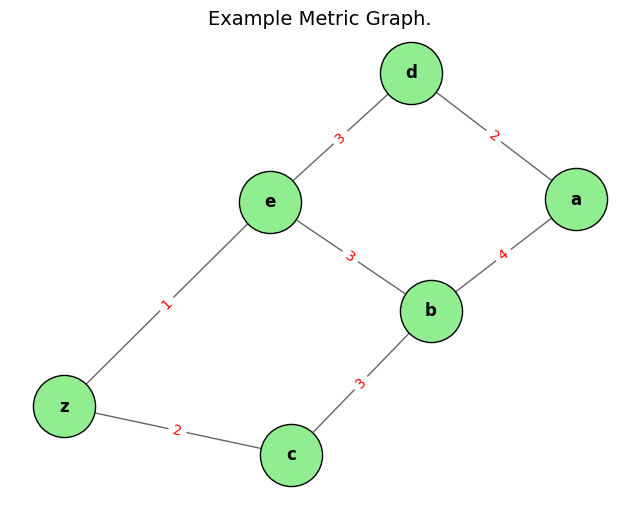

In [4]:
fig_num_1 = "1"
title_1 = "Example Metric Graph."
alt_text_1 = (
    "An undirected, weighted graph with six vertices labeled a, b, c, d, e, and z. "
    "The edges and their corresponding weights are: "
    "Edge (a, b) has weight 4. "
    "Edge (a, d) has weight 2. "
    "Edge (b, c) has weight 3. "
    "Edge (b, e) has weight 3. "
    "Edge (c, z) has weight 2. "
    "Edge (d, e) has weight 3. "
    "Edge (e, z) has weight 1. "
    "The graph forms a connected network where multiple paths exist between nodes, such as from 'a' to 'z'."
)

metric_graph_example.show(fig_num_1, title_1, alt_text_1)

## Section 18.2 - The Traveling Salesman Problem

Suppose you were a salesman and there were a number of cities where you needed to make your sales calls. Some of these cities are connected by roads, and each of these connecting roads has some corresponding distance. Assume it's always possible to find a sequence of roads from one city to another. You could formulate this as a connected metric graph, with the cities being vertices and the edges being roads with their weights being distances. The *traveling salesman problem* is the problem of figuring out the optimal circuit through the connected graph, where "optimal" here means the path that minimizes the total distance traveled. Note that the metric doesn't necessarily need to be distance, and could easily be something else you might want to optimize like transit time or cost.

A variant on this problem is the question of whether there's a circuit below a certain distance or cost. For example, suppose your metric is cost, your travel budget is \$2,000, and you want to know whether there is a circuit that hits every city that costs less than your budget. Note this circuit doesn't necessarily need to be the overall most cost efficient - it just needs to be one under \$2,000.

This problem of determining whether, for a given metric graph and value, there is a circuit through the graph with distance less than that value, is in NP. This is pretty straightforward. If you're provided with a metric graph, a value, and a sequence of vertices in the metric graph, you can quickly check whether that sequence is a circuit and if the total distance of that circuit is below that value. So, it's quick to *verify* whether the solution is correct. However, just given a metric graph and a value determining whether there is a circuit with total distance less than that value has no known polynomial time solution. So, it's not known whether the problem is in $P$, and strongly suspected it is not.

We can create a function for determining the cost of a given path within a metric graph and add it as a method to our MetricGraph class.

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# Method for determining the cost of a given path within a metric graph.
#
# ─────────────────────────────────────────────────────────────────────────────

def get_path_cost(self, path):
        """
        Calculates the total cost of a given sequence of vertices.
        Returns infinity if the path is invalid.
        """
        total_cost = 0
        for i in range(len(path) - 1):
            u, v = path[i], path[i+1]
            if v in self.graph[u]:
                total_cost += self.graph[u][v]
            else:
                return float('inf')
        return total_cost

In [6]:
# Add the path cost method to the metric graph class
MetricGraph.get_path_cost = get_path_cost

Checking this on the path $a \rightarrow b \rightarrow c \rightarrow z \rightarrow e \rightarrow d \rightarrow a$ in our example graph above returns the path's cost (distance).

In [7]:
circuit_example = ['a', 'b', 'c', 'z', 'e', 'd', 'a']
metric_graph_example.get_path_cost(circuit_example)

15

Using this, we can create a function for verifying whether a given path satisfied the traveling salesman problem below a given cost. We'll also add this function as a method to our MetricGraph class.

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# Method for varifying if a given path is withing budget.
#
# ─────────────────────────────────────────────────────────────────────────────

def verify_tsm_solution(self, path, budget):
        """
        Verifies if a path is a valid TSM circuit with cost <= budget.
        (The check mentioned in Section 18.2).
        """
        # 1. Check if start == end
        if path[0] != path[-1]:
            return False

        # 2. Check if all vertices visited exactly once (length check)
        if len(path) != len(self.graph) + 1:
            return False

        # 3. Check connectivity and cost
        cost = self.get_path_cost(path)
        return cost <= budget

In [9]:
# Add the verification method to the metric graph class.
MetricGraph.verify_tsm_solution = verify_tsm_solution

We can use this to check that for the metric graph example and our circuit above that the cost is below $20$ but above $10$.

In [10]:
metric_graph_example.verify_tsm_solution(circuit_example, 20)

True

In [11]:
metric_graph_example.verify_tsm_solution(['a', 'b', 'c', 'z'], 10)

False

## Section 18.3 - The Hamilton Path Problem and the Traveling Salesman Problem

In the previous chapter we discussed the Hamilton circuit problem, which is the problem of finding a circuit in a connected graph that visits each vertex (except the first and last one) exactly once. This problem, like the traveling salesman problem, is in $NP$, but it's not known if this problem is in $P$, and strongly suspected it is not.

Suppose by some miracle you figured out a polynomial time solution to the traveling salesman problem. In other words, suppose you had a polynomial time algorithm that could determine for a given connected metric graph and value whether there is a circuit in that graph with total distance less than that value. Well, in that case you'd also have a polynomial time solution to the Hamilton circuit problem!

The reason for this is that you can translate the Hamilton circuit problem into the traveling salesman problem in a polynomial amount of time. The way you'd do this is you'd take your connected graph and convert it to a metric graph by assigning to each edge the length of $1$. This can be done in an amount of time proportional to the number of edges, which is linear, and so definitely polynomial. Then, if there were $n$ vertices in the graph, you'd just check whether there is any circuit in the metric graph you created of length less than $n+1$. If the answer is yes, then that circuit would be a solution to the Hamilton path problem. If the answer is no, that would mean the original graph does not have a Hamilton circuit. As this last problem is the traveling salesman problem, if we can solve it in a polynomial amount of time, then we have a polynomial time solution to the Hamilton circuit problem.

We call this process of converting one problem into another a *reduction*, and if there is a polynomial time reduction from one problem to a second problem, and a polynomial time solution to the second problem, then a polynomial time solution to the first problem is to reduce it to the second and solve the second. So, if you can find a polynomial time solution to a problem, you've not only found an efficient solution for that problem, you've found an efficient solution for any other problem that can be efficiently reduced to it.

## Section 18.4 - Logical Satisfiability

We're going to briefly introduce the problem of logical satisfiability here. It's expected this is something you've seen before, and so this will be a somewhat terse review.

A *propositional variable* is a variable that can have two possible values - "true" and "false", denoted $T$ and $F$. There are three operators on propositional variables, and their rules are:

* $\neg$ means *negation* or "not", and the rule is that if $P$ is true, then $\neg P$ is false and vice-versa.
* $\land$ means *conjunction* or "and", and it combines two logical propositions into one with the rule that $P \land Q$ is true if and only if both $P$ and $Q$ are true.
* $\lor$ means *disjunction* or "or", and it combines two logical propositions into one with the rule that $P \lor Q$ is true if and only if either $P$ or $Q$, or both, are true.

Propositional logic statements are formed by combining propositional variables using the operators above and the rule that substatements within parentheses are evaluated first. Note you may have seen other logical operators like the implication $\rightarrow$, but these other operators can all be translated into equivalent statements using just the three operators above. For example, the implication $P \rightarrow Q$ is equivalent to $\neg P \lor Q$.

A logical statement is *satisfiable* if there is some assignment of truth values to its propositional variables that makes the entire statement true. We say such an assignment *satisfies* the statement. For example, the logical statement:

$$\displaystyle (P \lor Q) \land (P \lor \neg Q) \land (\neg P \lor Q)$$

is satisfied by the truth assignment $P = T, Q = T$. However, there is no assignment of truth values to $P$ and $Q$ that make the statement:

$$\displaystyle (P \lor Q) \land (P \lor \neg Q) \land (\neg P \lor Q) \land (\neg P \lor \neg Q)$$

true. Therefore, the second statement above is not satisfiable.

If we're given a logical statement and a truth assignment for its variables, it's easy (can be done in polynomial time) to verify whether the truth assignment works to make the entire statement true. If we're given a logical statement we can check if it's satisfiable by checking every possible truth assignment. However, if there are $N$ propositional variables in the statement, then there are $2^{N}$ possible truth assignments, and checking them all one-by-one requires an amount of time that is exponential (beyond polynomial) in the number of propositional variables. In other words, whether a logical statement is satisfiable (a problem called SAT) can be verified in a polynomial amount of time, but there is no known algorithm for determining whether any solution exists that runs in a polynomial amount of time, and it's strongly suspected no such algorithm exists. This is like the Hamilton circuit and traveling salesman problems.

## Section 18.5 - NP-Completeness

A remarkable result discovered in the early 1970s was that *every* NP problem (every problem for which a solution can be verified in a polynomial amount of time) can be reduced to a problem in SAT in a polynomial amount of time. This result is known as the Cook-Levin theroem, and it means that SAT is at least as "hard" as any other NP problem.

Now, any NP problem can be reduced in a polynomial amount of time to a problem in SAT. If SAT can also be reduced to an NP problem (like the Hamilton circuit problem or the traveling salesman problem) in a polynomial amount of time, then that means the other problem is also at least as "hard" as any other NP problem. This gives us an entire set of problems in NP that are at least as hard as any other problem in NP, and these problems are called NP-complete.

A great many NP-complete problems have been discovered, including SAT, the Hamilton path problem, and the traveling salesman problem, and more are discovered every year.

## Section 18.6 - Does P = NP?

Finding a polynomial time solution to any NP-complete problem would provide a polynomial time solution to all of them. It is strongly suspected that none exist. However, to date, nobody has been able to prove this, and it's the most significant open problem in theoretical computer science. In fact, it's such a significant open problem that when the Clay Mathematics Institute put forth a list of 7 problems for the 21st century, and placed a \$1,000,000 prize on each of them, one of the seven problems was the question of whether $P$ equals $NP$. To date (October, 2025) the 21st century is about a quarter of the way done, and only one of the seven problems (the Poincar&eacute; conjecture) has been solved. The question of whether $P = NP$ has not been yet been solved.

## Section 18.7 - References and Further Reading

* "Introduction to the Theory of Computation" (Third Edition) by Michael Sipser: *Sections 7.4-7.5 - NP-Completeness, Additional NP-complete problems*

* "Automata Theory, Languages, and Computation" (Third Edition) by John. E Hopcraft, Rajeev Matwani, and Jeffrey D. Ullman: *Sections 10.2-10.4 - An NP-Complete Problem, A Restricted Satisfiability Problem, Additional NP-Complete Problems*

* [P vs NP](https://https://www.claymath.org/millennium/p-vs-np/), Clay Mathematics Institute

## Section 18.8 - Practice Problems

### Problem 18.8.1 - Traveling Salesman Calculation

Consider a metric graph below:

In [12]:
problem_18_8_1_vertices = ['A', 'B', 'C']
problem_18_8_1_edges = [('A', 'B', 10), ('A', 'C', 20), ('B', 'C', 15)]

problem_18_8_1_graph = MetricGraph(vertices=problem_18_8_1_vertices, edges=problem_18_8_1_edges)


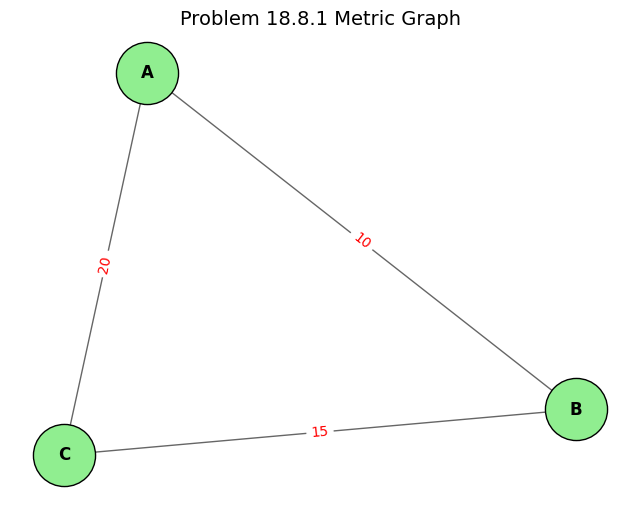

In [13]:
fig_num_2 = "2"
title_2 = "Problem 18.8.1 Metric Graph"
alt_text_2 = (
    "A complete, undirected, weighted graph with three vertices labeled A, B, and C. "
    "The graph forms a triangle, where all vertices are connected to each other. "
    "The edges and their weights are: (A, B) has weight 10; (A, C) has weight 20; and (B, C) has weight 15."
)

problem_18_8_1_graph.show(fig_num_2, title_2, alt_text_2)

What is the total cost of the traveling salesman circuit $A \rightarrow B \rightarrow C \rightarrow A$?

### Problem 18.8.2 - Reduction Logic

You have a "black box" algorithm that can solve the Traveling Salesman Problem (TSM) in polynomial time. Explain how you can use this specific box to solve the Hamilton circuit problem for a graph without weights.

### Problem 18.8.3 - SAT Verification

Determine if the following set of logical clauses is satisfiable. If yes, provide the truth values for A and B.

$$(A \lor B) \land (\neg A \lor B) \land (A \lor \neg B)$$

### Problem 18.8.4 - P vs NP Concepts

If a computer scientist proves that $P = NP$, what does that imply about the difficulty of solving the Traveling Salesman Problem compared to the difficulty of verifying a solution to it?

### Problem 18.8.5 - NP-Completeness

If Problem $X$ is NP-Complete, and you find a polynomial-time reduction from Problem $X$ to Problem $Y$, does that automatically make Problem $Y$ NP-Complete? (Assume $Y$ is in NP).

## Section 18.9 - Programming Problems

### Problem 18.9.1 - Graph Setup

Create a *MetricGraph* representing the following 4 cities and distances. Visualize it using the visualize method.

* Cities: New York, Chicago, Denver, LA

Distances:

* NY - Chicago: 800

* Chicago - Denver: 1000

* Denver - LA: 1000

* LA - NY: 2800

* NY - Denver: 1800

* Chicago - LA: 2000

In [ ]:
# YOUR CODE HERE

### Problem 18.9.2 - Budget Verification

Using the graph from Problem 18.9.1, determine if the circuit

<center>
['New York', 'Chicago', 'LA', 'Denver', 'New York']
</center>

is a valid solution for a budget of 5500.

In [ ]:
# YOUR CODE HERE

### Problem 18.9.3 - Route Comparison

Using the graph from Problem 18.9.1, calculate the cost of these two routes and determine which one is shorter using Python code:

1. ['New York', 'Chicago', 'Denver', 'LA', 'New York']

2. ['New York', 'Denver', 'Chicago', 'LA', 'New York']

In [ ]:
# YOUR CODE HERE

### Problem 18.9.4 - Traveling Salesman Brute Force (Challenge)

Write a function for solving the traveling salesman problem (most efficient circuit) for a instance of our MetricGraph class using brute force, and add it as a method to the class.

In [ ]:
# YOUR CODE HERE

Then, use this method to find a solution for the following MetricGraph instance of a $K_{5}$ graph with edge weights.

In [14]:
# A complete graph with 5 nodes (K5)
tsm_vertices = ['A', 'B', 'C', 'D', 'E']
tsm_edges = [
    ('A', 'B', 2),  ('A', 'C', 4),  ('A', 'D', 7),  ('A', 'E', 3),
    ('B', 'C', 5),  ('B', 'D', 2),  ('B', 'E', 6),
    ('C', 'D', 4),  ('C', 'E', 3),
    ('D', 'E', 5)
]

tsm_graph = MetricGraph(vertices=tsm_vertices, edges=tsm_edges)


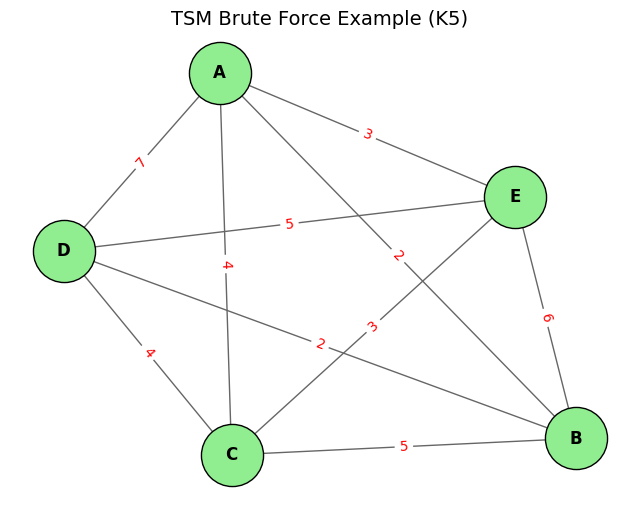

In [15]:
fig_num_3 = "3"
title_3 = "TSM Brute Force Example (K5)"
alt_text_3 = (
    "A complete, undirected, weighted graph with five vertices labeled A, B, C, D, and E. "
    "The graph is a complete graph (K-5), meaning it contains 10 edges, connecting every pair of vertices. "
    "The edge weights are: (A, B) = 2, (A, C) = 4, (A, D) = 7, (A, E) = 3. "
    "The remaining edge weights are: (B, C) = 5, (B, D) = 2, (B, E) = 6. "
    "The remaining edge weights are: (C, D) = 4, (C, E) = 3, and (D, E) = 5."
)

tsm_graph.show(fig_num_3, title_3, alt_text_3)

In [ ]:
# YOUR CODE HERE